In [7]:
# extract_images_page33.py
# Works with Python 3.8+

from PyPDF2 import PdfReader, PdfWriter
import os

# ==================== CONFIGURE HERE ====================
pdf_path = "p_s-pim-ss2024-meeting3-afterlecture.pdf"    # <<< CHANGE THIS to your PDF name
output_folder = "images_from_page_33"  # Folder where images will be saved
create_pdf_without_images = False       # Set False if you don't want the cleaned PDF
# ========================================================

# Create output folder
os.makedirs(output_folder, exist_ok=True)

reader = PdfReader(pdf_path)
writer = PdfWriter()

# Page numbers in PyPDF2 are 0-based, so page 33 = index 32
page_index = 32  
if len(reader.pages) < 33:
    print("Error: Your PDF has only", len(reader.pages), "pages. No page 33.")
    exit()

page = reader.pages[page_index]
images_found = 0

print(f"Processing page 33 ({page_index + 1} of {len(reader.pages)})")

if "/XObject" in page["/Resources"]:
    xObject = page["/Resources"]["/XObject"].get_object()
    
    for i, obj_name in enumerate(xObject):
        obj = xObject[obj_name]
        if obj["/Subtype"] == "/Image":
            images_found += 1
            
            # Determine file extension
            if "/Filter" in obj:
                if obj["/Filter"] == "/DCTDecode":
                    ext = ".jpg"
                elif obj["/Filter"] == "/JPXDecode":
                    ext = ".jp2"
                elif obj["/Filter"] == "/CCITTFaxDecode":
                    ext = ".tiff"
                else:
                    ext = ".pdf"
            else:
                ext = ".pdf"
            
            # Save the image
            filename = f"{output_folder}/page33_image_{images_found}{ext}"
            with open(filename, "wb") as img_file:
                img_file.write(obj.get_data())
            
            print(f"  → Saved: {filename}")
            
            # Optional: remove this image from the page
            if create_pdf_without_images:
                del xObject[obj_name]  # This removes the image reference

# Add all pages to writer (page 33 now has images removed if you enabled it)
for i, p in enumerate(reader.pages):
    writer.add_page(p)

# Save the new PDF without the images from page 33 (if requested)
if create_pdf_without_images:
    output_pdf = pdf_path.replace(".pdf", "_without_page33_images.pdf")
    with open(output_pdf, "wb") as f:
        writer.write(f)
    print(f"\nNew PDF without images from page 33 saved as:\n→ {output_pdf}")

if images_found == 0:
    print("No images found on page 33.")
else:
    print(f"\nDone! Extracted {images_found} image(s) to folder: {output_folder}")

Processing page 33 (33 of 104)
  → Saved: images_from_page_33/page33_image_1.pdf

Done! Extracted 1 image(s) to folder: images_from_page_33


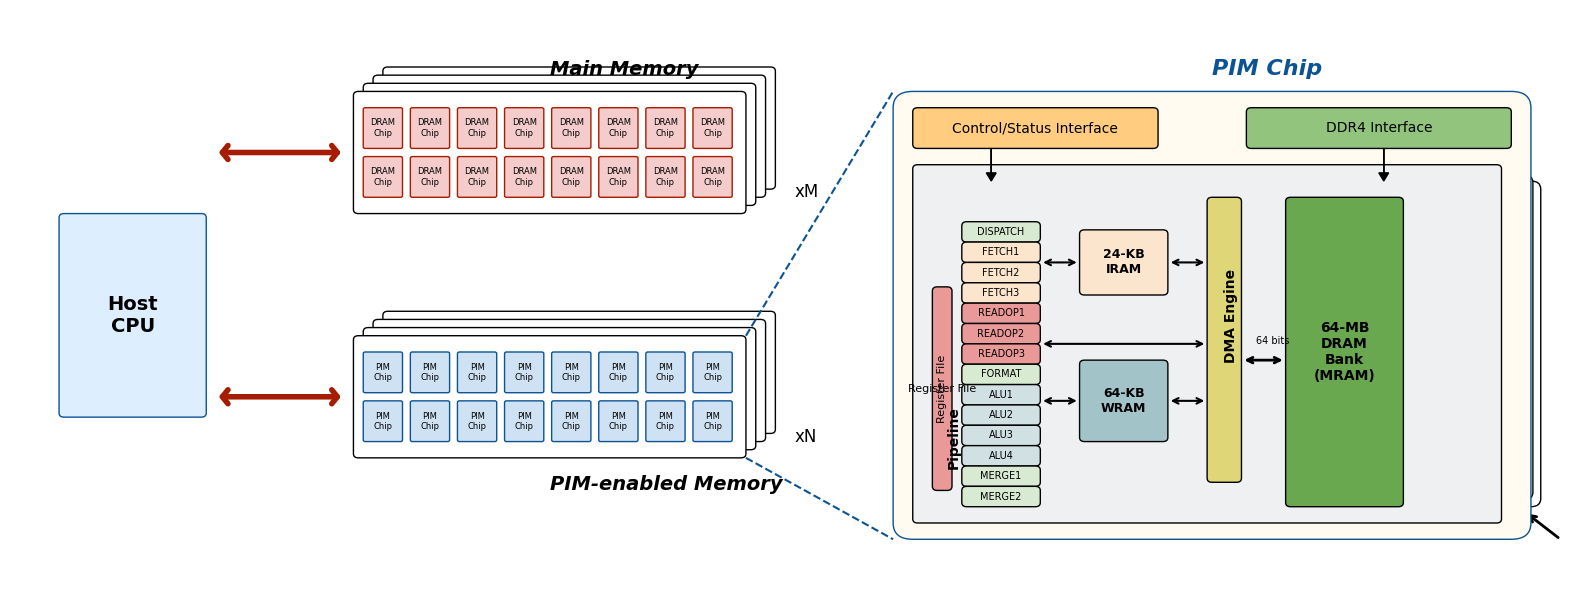

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_rounded_rect(ax, x, y, w, h, color, ec='black', radius=0.5, label=None, fontsize=10, bold=False, zorder=10):
    """
    Helper to draw rounded rectangles.
    Now accepts 'zorder' explicitly to handle layering.
    """
    box = patches.FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0,rounding_size={radius}",
                                 facecolor=color, edgecolor=ec, linewidth=1, zorder=zorder)
    ax.add_patch(box)
    
    if label:
        weight = 'bold' if bold else 'normal'
        # Text zorder must be higher than the box zorder so it appears on top
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=fontsize, weight=weight, zorder=zorder+1)
    return box

def draw_stack_effect(ax, x, y, w, h, color, layers=3, x_offset=1, y_offset=1):
    """Helper to draw the 3D stack effect behind a main box"""
    for i in range(layers, 0, -1):
        # Draw layers back to front
        rect = patches.FancyBboxPatch((x + (i*x_offset), y + (i*y_offset)), w, h,
                                      boxstyle="round,pad=0,rounding_size=0.5",
                                      facecolor='white', edgecolor='black', linewidth=1, zorder=1)
        ax.add_patch(rect)

def create_pim_architecture_diagram():
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_xlim(0, 160)
    ax.set_ylim(0, 70)
    ax.axis('off') # Hide axes

    # ==========================================
    # LEFT SIDE: Host and Memories
    # ==========================================

    # 1. Host CPU
    draw_rounded_rect(ax, 5, 20, 15, 25, '#dceeff', label="Host\nCPU", fontsize=14, bold=True, ec='#0b5394')

    # 2. Main Memory (Top Stack)
    mm_x, mm_y = 35, 45
    draw_stack_effect(ax, mm_x, mm_y, 40, 15, 'white', layers=3)
    # Main Face
    draw_rounded_rect(ax, mm_x, mm_y, 40, 15, 'white')
    # Internal DRAM Chips (Grid)
    for row in range(2):
        for col in range(8):
            bx = mm_x + 1 + (col * 4.8)
            by = mm_y + 8 - (row * 6)
            draw_rounded_rect(ax, bx, by, 4, 5, '#f4cccc', label="DRAM\nChip", fontsize=6, ec='#a61c00', radius=0.2)
    
    ax.text(mm_x + 20, mm_y + 17, "Main Memory", fontsize=14, weight='bold', style='italic')
    ax.text(mm_x + 45, mm_y + 2, "xM", fontsize=12) # Stack label
    
    # 3. PIM-enabled Memory (Bottom Stack)
    pim_x, pim_y = 35, 15
    draw_stack_effect(ax, pim_x, pim_y, 40, 15, 'white', layers=3)
    draw_rounded_rect(ax, pim_x, pim_y, 40, 15, 'white')
    # Internal PIM Chips (Grid)
    for row in range(2):
        for col in range(8):
            bx = pim_x + 1 + (col * 4.8)
            by = pim_y + 8 - (row * 6)
            draw_rounded_rect(ax, bx, by, 4, 5, '#cfe2f3', label="PIM\nChip", fontsize=6, ec='#0b5394', radius=0.2)

    ax.text(pim_x + 20, pim_y - 4, "PIM-enabled Memory", fontsize=14, weight='bold', style='italic')
    ax.text(pim_x + 45, pim_y + 2, "xN", fontsize=12)

    # Arrows (Host <-> Memory)
    ax.annotate("", xy=(34, 52.5), xytext=(21, 52.5), arrowprops=dict(arrowstyle="<->, head_width=0.5", color='#a61c00', lw=4))
    ax.annotate("", xy=(34, 22.5), xytext=(21, 22.5), arrowprops=dict(arrowstyle="<->, head_width=0.5", color='#a61c00', lw=4))

    # ==========================================
    # RIGHT SIDE: Zoomed PIM Chip
    # ==========================================
    
    chip_base_x = 90
    chip_base_y = 5
    chip_w = 65
    chip_h = 55
    
    # Zoom dashed lines
    line_props = dict(color='#0b5394', linestyle='--', linewidth=1.5)
    ax.plot([pim_x + 40, chip_base_x], [pim_y + 15, chip_base_y + chip_h], **line_props) # Top line
    ax.plot([pim_x + 40, chip_base_x], [pim_y, chip_base_y], **line_props) # Bottom line

    # Main Chip Container
    draw_rounded_rect(ax, chip_base_x, chip_base_y, chip_w, chip_h, '#fffbf0', ec='#0b5394', radius=2)
    ax.text(chip_base_x + chip_w/2, chip_base_y + chip_h + 2, "PIM Chip", fontsize=16, weight='bold', color='#0b5394', style='italic')

    # Interfaces (Top)
    draw_rounded_rect(ax, chip_base_x + 2, chip_base_y + 48, 25, 5, '#ffcc80', label="Control/Status Interface", fontsize=10)
    draw_rounded_rect(ax, chip_base_x + 36, chip_base_y + 48, 27, 5, '#93c47d', label="DDR4 Interface", fontsize=10)
    
    # Internal Stack Effect (The Banks)
    stack_x = chip_base_x + 2
    stack_y = chip_base_y + 2
    stack_w = 60
    stack_h = 44
    
    # Draw multiple offset rectangles for the "Bank Stack"
    for i in range(5):
        offset = i * 0.8
        rect = patches.FancyBboxPatch((stack_x + 4 - offset, stack_y + 2 + offset), stack_w, stack_h - 4,
                                      boxstyle="round,pad=0,rounding_size=1",
                                      facecolor='white', edgecolor='black', zorder=5+i)
        ax.add_patch(rect)
    
    # The Top "Detailed" Bank Layer
    top_layer_z = 20
    bank_x = stack_x
    bank_y = stack_y
    # Background for the top layer components - THIS WAS THE FIX (passing zorder)
    draw_rounded_rect(ax, bank_x, bank_y, stack_w, stack_h, '#eff0f1', zorder=top_layer_z)

    # --- Internal Components ---
    
    # 1. Pipeline (Left side of bank)
    pipe_x = bank_x + 2
    pipe_y = bank_y + 2
    pipe_w = 8
    
    # Pipeline stages data
    stages = [
        ('DISPATCH', '#d9ead3'), ('FETCH1', '#fce5cd'), ('FETCH2', '#fce5cd'), ('FETCH3', '#fce5cd'),
        ('READOP1', '#ea9999'), ('READOP2', '#ea9999'), ('READOP3', '#ea9999'),
        ('FORMAT', '#d9ead3'), 
        ('ALU1', '#d0e0e3'), ('ALU2', '#d0e0e3'), ('ALU3', '#d0e0e3'), ('ALU4', '#d0e0e3'),
        ('MERGE1', '#d9ead3'), ('MERGE2', '#d9ead3')
    ]
    
    stage_h = 2.5
    current_y = pipe_y + (len(stages) * stage_h)
    
    # Register File Strip
    draw_rounded_rect(ax, pipe_x, pipe_y + 2, 2, 25, '#ea9999', label="Register File", fontsize=8, ec='black', zorder=top_layer_z + 1)
    ax.text(pipe_x + 1, pipe_y + 14.5, "Register File", rotation=90, fontsize=8, va='center', ha='center', zorder=top_layer_z + 2)
    
    # Draw Pipeline Stages
    for name, color in stages:
        current_y -= stage_h
        draw_rounded_rect(ax, pipe_x + 3, current_y, 8, stage_h, color, label=name, fontsize=7, zorder=top_layer_z + 1)
    
    # Label "Pipeline"
    ax.text(pipe_x + 1.5, pipe_y + 5, "Pipeline", rotation=90, weight='bold', fontsize=10, zorder=top_layer_z + 2)

    # 2. Memory Blocks (Center)
    iram_x = pipe_x + 15
    wram_x = pipe_x + 15
    
    # IRAM
    draw_rounded_rect(ax, iram_x, bank_y + 28, 9, 8, '#fce5cd', label="24-KB\nIRAM", fontsize=9, bold=True, zorder=top_layer_z + 1)
    # WRAM
    draw_rounded_rect(ax, wram_x, bank_y + 10, 9, 10, '#a2c4c9', label="64-KB\nWRAM", fontsize=9, bold=True, zorder=top_layer_z + 1)
    
    # 3. DMA Engine
    dma_x = iram_x + 13
    draw_rounded_rect(ax, dma_x, bank_y + 5, 3.5, 35, '#dfd678', label="", fontsize=9, zorder=top_layer_z + 1)
    ax.text(dma_x + 1.75, bank_y + 20, "DMA Engine", rotation=90, weight='bold', fontsize=10, zorder=top_layer_z + 2)

    # 4. DRAM Bank (Right)
    mram_x = dma_x + 8
    draw_rounded_rect(ax, mram_x, bank_y + 2, 12, 38, '#6aa84f', label="64-MB\nDRAM\nBank\n(MRAM)", fontsize=10, bold=True, zorder=top_layer_z + 1)
    
    # Stack label x8
    ax.annotate("x8", xy=(chip_base_x + chip_w + 3, chip_base_y), xytext=(chip_base_x + chip_w - 3, chip_base_y + 4),
                arrowprops=dict(arrowstyle="<-", lw=2), fontsize=12)

    # --- Internal Arrows ---
    # Interfaces to Internal
    ax.arrow(chip_base_x + 10, chip_base_y + 48, 0, -3, head_width=1, head_length=1, fc='black', ec='black', zorder=top_layer_z + 2)
    ax.arrow(chip_base_x + 50, chip_base_y + 48, 0, -3, head_width=1, head_length=1, fc='black', ec='black', zorder=top_layer_z + 2)
    
    # Horizontal arrows inside
    kw = dict(arrowstyle="<->", color='black', lw=1.5)
    
    # Pipeline <-> IRAM
    ax.annotate("", xy=(pipe_x + 11, bank_y + 32), xytext=(iram_x, bank_y + 32), arrowprops=kw, zorder=top_layer_z + 2)
    # Pipeline <-> WRAM
    ax.annotate("", xy=(pipe_x + 11, bank_y + 15), xytext=(wram_x, bank_y + 15), arrowprops=kw, zorder=top_layer_z + 2)
    # Pipeline <-> DMA (Long line)
    ax.annotate("", xy=(pipe_x + 11, bank_y + 22), xytext=(dma_x, bank_y + 22), arrowprops=kw, zorder=top_layer_z + 2)
    # IRAM <-> DMA
    ax.annotate("", xy=(iram_x + 9, bank_y + 32), xytext=(dma_x, bank_y + 32), arrowprops=kw, zorder=top_layer_z + 2)
    # WRAM <-> DMA
    ax.annotate("", xy=(wram_x + 9, bank_y + 15), xytext=(dma_x, bank_y + 15), arrowprops=kw, zorder=top_layer_z + 2)
    # DMA <-> MRAM
    ax.annotate("", xy=(dma_x + 3.5, bank_y + 20), xytext=(mram_x, bank_y + 20), arrowprops=dict(arrowstyle="<->", color='black', lw=2), zorder=top_layer_z + 2)
    ax.text(dma_x + 5, bank_y + 22, "64 bits", fontsize=7, zorder=top_layer_z + 3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    create_pim_architecture_diagram()

Diagram saved as 'pim_architecture_diagram.png' and 'pim_architecture_diagram.svg'


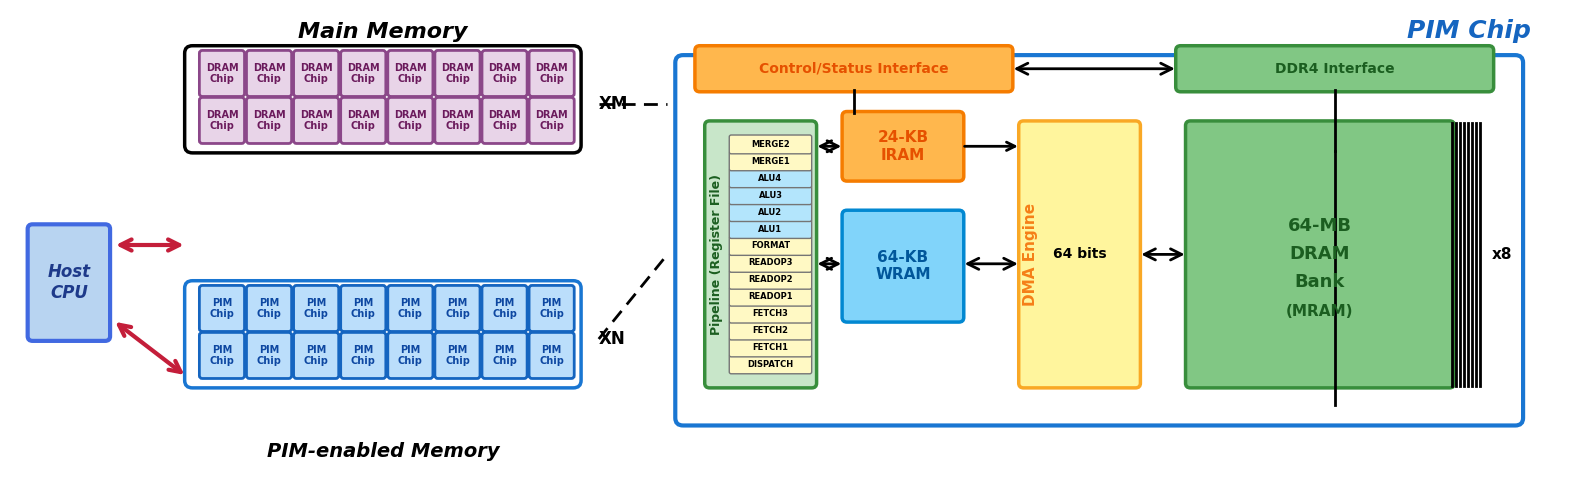

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ConnectionPatch
from matplotlib.path import Path
import matplotlib.patches as patches
import numpy as np

# Create figure with transparent background
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 5)
ax.axis('off')
fig.patch.set_alpha(0)

# Helper function for rounded rectangles
def add_rounded_rect(ax, xy, width, height, facecolor, edgecolor, linewidth=2, radius=0.1, label='', fontsize=10, fontweight='bold', fontcolor='black', italic=False):
    box = FancyBboxPatch(xy, width, height, boxstyle=f"round,pad=0.02,rounding_size={radius}", 
                         facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth)
    ax.add_patch(box)
    if label:
        style = 'italic' if italic else 'normal'
        ax.text(xy[0] + width/2, xy[1] + height/2, label, ha='center', va='center', 
                fontsize=fontsize, fontweight=fontweight, color=fontcolor, style=style)

# Helper function for double-headed arrows
def add_double_arrow(ax, x1, y1, x2, y2, color='red', linewidth=3):
    arrow1 = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='<->', mutation_scale=20, 
                            linewidth=linewidth, color=color)
    ax.add_patch(arrow1)

# Helper function for single arrow
def add_arrow(ax, x1, y1, x2, y2, color='black', linewidth=2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=15, 
                           linewidth=linewidth, color=color)
    ax.add_patch(arrow)

# 1. HOST CPU (left side)
add_rounded_rect(ax, (0.2, 1.5), 0.8, 1.2, facecolor='#B8D4F1', edgecolor='#4169E1', 
                linewidth=3, radius=0.05, label='Host\nCPU', fontsize=12, fontweight='bold', 
                fontcolor='#1E3A8A', italic=True)

# Double arrows from Host CPU
add_double_arrow(ax, 1.05, 2.5, 1.8, 2.5, color='#C41E3A', linewidth=3)
add_double_arrow(ax, 1.05, 1.7, 1.8, 1.1, color='#C41E3A', linewidth=3)

# 2. MAIN MEMORY section
ax.text(3.8, 4.7, 'Main Memory', fontsize=16, fontweight='bold', style='italic', ha='center')

# Main Memory container with rounded corners
main_mem_rect = FancyBboxPatch((1.8, 3.5), 4.0, 1.1, boxstyle="round,pad=0.02,rounding_size=0.08",
                               facecolor='white', edgecolor='black', linewidth=2.5)
ax.add_patch(main_mem_rect)

# DRAM chips in Main Memory (2 rows x 8 columns)
chip_width = 0.42
chip_height = 0.45
x_start = 1.95
y_start = 3.6

for row in range(2):
    for col in range(8):
        x = x_start + col * 0.48
        y = y_start + row * 0.5
        add_rounded_rect(ax, (x, y), chip_width, chip_height, 
                        facecolor='#E8D4E8', edgecolor='#8B4789', linewidth=2, 
                        radius=0.03, label='DRAM\nChip', fontsize=7, fontweight='bold', 
                        fontcolor='#6B1A5C')

# XM label
ax.text(6.0, 4.0, 'XM', fontsize=12, fontweight='bold', ha='left', va='center')

# 3. PIM-ENABLED MEMORY section
ax.text(3.8, 0.25, 'PIM-enabled Memory', fontsize=14, fontweight='bold', style='italic', ha='center')

# PIM Memory container
pim_mem_rect = FancyBboxPatch((1.8, 1.0), 4.0, 1.1, boxstyle="round,pad=0.02,rounding_size=0.08",
                              facecolor='white', edgecolor='#1976D2', linewidth=2.5)
ax.add_patch(pim_mem_rect)

# PIM chips (2 rows x 8 columns)
for row in range(2):
    for col in range(8):
        x = x_start + col * 0.48
        y = 1.1 + row * 0.5
        add_rounded_rect(ax, (x, y), chip_width, chip_height, 
                        facecolor='#BBDEFB', edgecolor='#1565C0', linewidth=2, 
                        radius=0.03, label='PIM\nChip', fontsize=7, fontweight='bold', 
                        fontcolor='#0D47A1')

# XN label
ax.text(6.0, 1.5, 'XN', fontsize=12, fontweight='bold', ha='left', va='center')

# Dashed lines to PIM Chip section
ax.plot([6.0, 6.7], [4.0, 4.0], 'k--', linewidth=2, dashes=(5, 3))
ax.plot([6.0, 6.7], [1.5, 2.4], 'k--', linewidth=2, dashes=(5, 3))

# 4. PIM CHIP detailed architecture (right side)
ax.text(15.5, 4.7, 'PIM Chip', fontsize=18, fontweight='bold', style='italic', 
        ha='right', color='#1565C0')

# Main PIM Chip container
pim_chip_rect = FancyBboxPatch((6.8, 0.6), 8.6, 3.9, boxstyle="round,pad=0.02,rounding_size=0.08",
                               facecolor='white', edgecolor='#1976D2', linewidth=3)
ax.add_patch(pim_chip_rect)

# Control/Status Interface
add_rounded_rect(ax, (7.0, 4.15), 3.2, 0.45, facecolor='#FFB74D', edgecolor='#F57C00', 
                linewidth=2.5, radius=0.05, label='Control/Status Interface', 
                fontsize=10, fontweight='bold', fontcolor='#E65100')

# DDR4 Interface
add_rounded_rect(ax, (11.9, 4.15), 3.2, 0.45, facecolor='#81C784', edgecolor='#388E3C', 
                linewidth=2.5, radius=0.05, label='DDR4 Interface', 
                fontsize=10, fontweight='bold', fontcolor='#1B5E20')

# Double arrow between Control and DDR4
add_double_arrow(ax, 10.2, 4.375, 11.9, 4.375, color='black', linewidth=2)

# Vertical lines from interfaces
ax.plot([8.6, 8.6], [4.15, 3.9], 'k-', linewidth=2)
ax.plot([13.5, 13.5], [4.15, 3.5], 'k-', linewidth=2)

# Pipeline (Register File)
pipeline_rect = FancyBboxPatch((7.1, 1.0), 1.1, 2.8, boxstyle="round,pad=0.02,rounding_size=0.05",
                               facecolor='#C8E6C9', edgecolor='#388E3C', linewidth=2.5)
ax.add_patch(pipeline_rect)
ax.text(7.2, 2.4, 'Pipeline (Register File)', fontsize=9, fontweight='bold', 
        rotation=90, va='center', ha='center', color='#1B5E20')

# Pipeline stages
stages = ['DISPATCH', 'FETCH1', 'FETCH2', 'FETCH3', 'READOP1', 'READOP2', 'READOP3', 
          'FORMAT', 'ALU1', 'ALU2', 'ALU3', 'ALU4', 'MERGE1', 'MERGE2']
stage_height = 0.18
y_start_stage = 1.15

for i, stage in enumerate(stages):
    y = y_start_stage + i * stage_height
    color = '#FFF9C4' if 'FETCH' in stage or 'READOP' in stage or stage in ['DISPATCH', 'FORMAT', 'MERGE1', 'MERGE2'] else '#B3E5FC'
    add_rounded_rect(ax, (7.35, y), 0.8, 0.16, facecolor=color, edgecolor='#757575', 
                    linewidth=1, radius=0.02, label=stage, fontsize=6, fontweight='bold', 
                    fontcolor='#000000')

# 24-KB IRAM
add_rounded_rect(ax, (8.5, 3.2), 1.2, 0.7, facecolor='#FFB74D', edgecolor='#F57C00', 
                linewidth=2.5, radius=0.05, label='24-KB\nIRAM', fontsize=11, 
                fontweight='bold', fontcolor='#E65100')

# Arrows between Pipeline and IRAM
add_double_arrow(ax, 8.2, 3.55, 8.5, 3.55, color='black', linewidth=2)

# 64-KB WRAM
add_rounded_rect(ax, (8.5, 1.7), 1.2, 1.15, facecolor='#81D4FA', edgecolor='#0288D1', 
                linewidth=2.5, radius=0.05, label='64-KB\nWRAM', fontsize=11, 
                fontweight='bold', fontcolor='#01579B')

# Arrows between Pipeline and WRAM
add_double_arrow(ax, 8.2, 2.3, 8.5, 2.3, color='black', linewidth=2)

# DMA Engine
dma_rect = FancyBboxPatch((10.3, 1.0), 1.2, 2.8, boxstyle="round,pad=0.02,rounding_size=0.05",
                          facecolor='#FFF59D', edgecolor='#F9A825', linewidth=2.5)
ax.add_patch(dma_rect)
ax.text(10.4, 2.4, 'DMA Engine', fontsize=11, fontweight='bold', 
        rotation=90, va='center', ha='center', color='#F57F17')

# 64 bits label
ax.text(10.9, 2.4, '64 bits', fontsize=10, fontweight='bold', ha='center', va='center')

# Arrow from IRAM to DMA Engine
add_arrow(ax, 9.7, 3.55, 10.3, 3.55, color='black', linewidth=2)

# Double arrow between WRAM and DMA Engine
add_double_arrow(ax, 9.7, 2.3, 10.3, 2.3, color='black', linewidth=2)

# 64-MB DRAM Bank (MRAM)
dram_rect = FancyBboxPatch((12.0, 1.0), 2.7, 2.8, boxstyle="round,pad=0.02,rounding_size=0.05",
                           facecolor='#81C784', edgecolor='#388E3C', linewidth=2.5)
ax.add_patch(dram_rect)
ax.text(13.35, 2.65, '64-MB', fontsize=13, fontweight='bold', ha='center', color='#1B5E20')
ax.text(13.35, 2.35, 'DRAM', fontsize=13, fontweight='bold', ha='center', color='#1B5E20')
ax.text(13.35, 2.05, 'Bank', fontsize=13, fontweight='bold', ha='center', color='#1B5E20')
ax.text(13.35, 1.75, '(MRAM)', fontsize=11, fontweight='bold', ha='center', color='#1B5E20')

# Double arrow between DMA Engine and DRAM Bank
add_double_arrow(ax, 11.5, 2.4, 12.0, 2.4, color='black', linewidth=2)

# Multiple connection lines to DRAM Bank (x8)
for i in range(8):
    x = 14.7 + i * 0.04
    ax.plot([x, x], [1.0, 3.8], 'k-', linewidth=2)

# x8 label
ax.text(15.1, 2.4, 'x8', fontsize=11, fontweight='bold', ha='left', va='center')

# Vertical connection from DDR4 to DRAM
ax.plot([13.5, 13.5], [3.5, 0.8], 'k-', linewidth=2)

# Save with transparent background
plt.tight_layout()
plt.savefig('pim_architecture_diagram.png', dpi=300, bbox_inches='tight', 
            facecolor='none', edgecolor='none', transparent=True)
plt.savefig('pim_architecture_diagram.svg', bbox_inches='tight', 
            facecolor='none', edgecolor='none', transparent=True)
print("Diagram saved as 'pim_architecture_diagram.png' and 'pim_architecture_diagram.svg'")
plt.show()

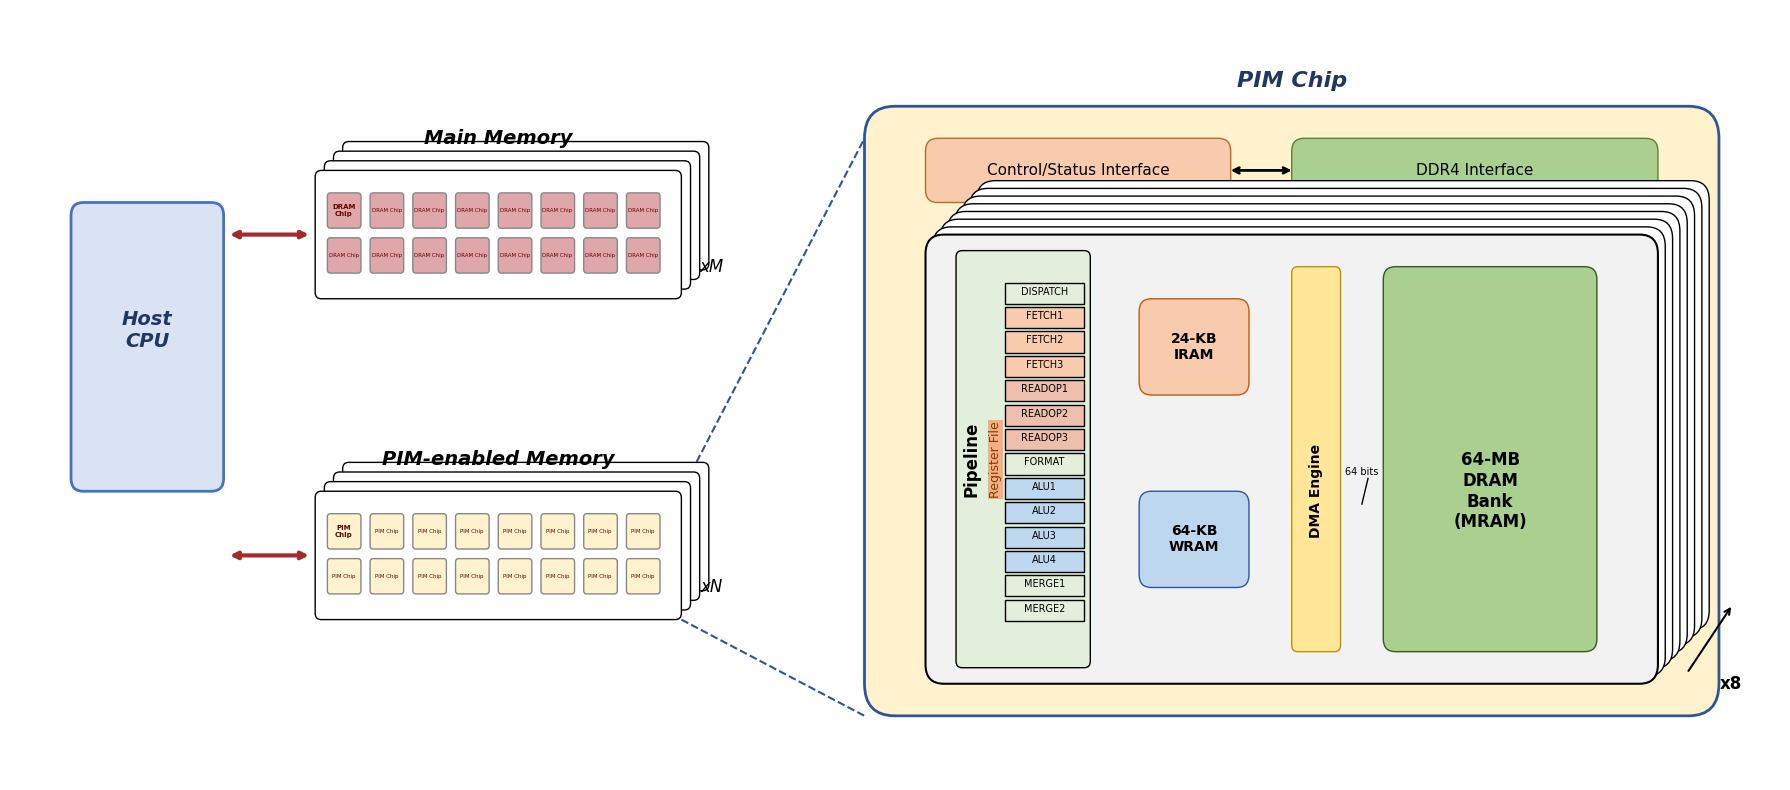

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np

# --- Configuration & Style ---
COLORS = {
    'cpu_fill': '#dae3f3',
    'cpu_edge': '#4472c4',
    'dimm_fill': '#ffffff',
    'dram_chip': '#dfa7a9',  # Pinkish
    'pim_chip_small': '#fff2cc', # Light yellow
    'pim_bg': '#fff2cc',
    'pim_edge': '#2f5597',
    'interface_orange': '#f8cbad',
    'interface_green': '#a9d08e',
    'iram': '#f8cbad',
    'wram': '#bdd7ee',
    'dma': '#ffe699',
    'mram': '#a9d08e',
    'pipeline_bg': '#e2efda',
    'pipe_green': '#d6dce4', 
    'pipe_orange': '#f4b084',
    'pipe_red': '#eebfac', 
    'text_main': 'black',
    'text_blue': '#203764'
}

def create_rounded_rect(xy, width, height, radius=0.1, **kwargs):
    """Creates a fancy box with rounded corners."""
    return patches.FancyBboxPatch(
        xy, width, height,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        **kwargs
    )

def draw_arrow(ax, start, end, color='black', style='<->', lw=1.5):
    """Draws an arrow between two points."""
    ax.annotate(
        '', xy=end, xytext=start,
        arrowprops=dict(arrowstyle=style, color=color, lw=lw, shrinkA=0, shrinkB=0)
    )

def add_text(ax, xy, text, size=10, color='black', weight='normal', align='center', rotation=0, zorder=10, **kwargs):
    """
    Adds text to the plot. 
    zorder is now an explicit argument to prevent collision with kwargs.
    """
    ax.text(xy[0], xy[1], text, fontsize=size, color=color, 
            ha=align, va='center', weight=weight, rotation=rotation, zorder=zorder, **kwargs)

# --- Drawing Components ---

def draw_left_side(ax):
    """Draws the Host CPU and Memory Banks."""
    
    # 1. Host CPU
    cpu_rect = create_rounded_rect((0, 3.5), 2.5, 4.5, radius=0.2, 
                                   facecolor=COLORS['cpu_fill'], edgecolor=COLORS['cpu_edge'], linewidth=2)
    ax.add_patch(cpu_rect)
    add_text(ax, (1.25, 6), "Host\nCPU", size=14, color=COLORS['text_blue'], weight='bold', style='italic')

    # Helper to draw a DIMM Stack
    def draw_dimm_stack(start_y, label, chip_color, stack_label, chip_text="DRAM\nChip"):
        # Draw shadow/stack effect
        for i in range(3, 0, -1):
            offset = i * 0.15
            rect = create_rounded_rect((4 + offset, start_y + offset), 6, 2, radius=0.1,
                                       facecolor='white', edgecolor='black', zorder=10-i)
            ax.add_patch(rect)
        
        # Front DIMM
        front_rect = create_rounded_rect((4, start_y), 6, 2, radius=0.1,
                                         facecolor='white', edgecolor='black', zorder=11)
        ax.add_patch(front_rect)
        
        # Draw Chips inside
        for r in range(2):
            for c in range(8):
                cx = 4.2 + c * 0.7
                cy = start_y + 1.1 - r * 0.7
                chip = create_rounded_rect((cx, cy), 0.55, 0.55, radius=0.05,
                                           facecolor=chip_color, edgecolor='#888', zorder=12)
                ax.add_patch(chip)
                if c == 0 and r == 0: 
                    add_text(ax, (cx + 0.27, cy + 0.27), chip_text, size=5, weight='bold', color='#660000', zorder=13)
                elif c < 8:
                     add_text(ax, (cx + 0.27, cy + 0.27), chip_text.replace('\n', ' '), size=4, color='#660000', zorder=13)

        # Main Labels
        add_text(ax, (7, start_y + 2.5), label, size=14, weight='bold', style='italic')
        # Arrow from CPU
        draw_arrow(ax, (2.6, start_y + 1), (3.9, start_y + 1), color='#a52a2a', lw=3)
        # Stack Label (xM / xN)
        add_text(ax, (10.5, start_y + 0.5), stack_label, size=12, style='italic')

    # Draw Main Memory
    draw_dimm_stack(6.5, "Main Memory", COLORS['dram_chip'], "xM", "DRAM\nChip")
    
    # Draw PIM Memory
    draw_dimm_stack(1.5, "PIM-enabled Memory", COLORS['pim_chip_small'], "xN", "PIM\nChip")

    # Dashed lines connecting to detail view
    src_x, src_y = 10, 1.5
    ax.plot([src_x, 13], [src_y, 0], color='#2f5597', linestyle='--', lw=1.5) # Bottom line
    ax.plot([src_x, 13], [src_y + 2, 9], color='#2f5597', linestyle='--', lw=1.5) # Top line

def draw_pim_detail(ax):
    """Draws the detailed PIM Chip architecture on the right."""
    base_x, base_y = 13, 0
    width, height = 14, 9.5
    
    # Main Container
    container = create_rounded_rect((base_x, base_y), width, height, radius=0.5,
                                    facecolor=COLORS['pim_bg'], edgecolor=COLORS['pim_edge'], linewidth=2)
    ax.add_patch(container)
    add_text(ax, (base_x + width/2, base_y + height + 0.4), "PIM Chip", size=16, 
             color=COLORS['text_blue'], weight='bold', style='italic')

    # Top Interfaces
    # Control/Status
    cs_rect = create_rounded_rect((base_x + 1, base_y + 8), 5, 1, radius=0.2,
                                  facecolor=COLORS['interface_orange'], edgecolor='#b56a35')
    ax.add_patch(cs_rect)
    add_text(ax, (base_x + 3.5, base_y + 8.5), "Control/Status Interface", size=11)

    # DDR4
    ddr_rect = create_rounded_rect((base_x + 7, base_y + 8), 6, 1, radius=0.2,
                                   facecolor=COLORS['interface_green'], edgecolor='#548235')
    ax.add_patch(ddr_rect)
    add_text(ax, (base_x + 10, base_y + 8.5), "DDR4 Interface", size=11)

    # Interface Arrow
    draw_arrow(ax, (base_x + 6, base_y + 8.5), (base_x + 7, base_y + 8.5), style='<->', lw=2)

    # --- Internal Stack (The 3D Slices) ---
    stack_x, stack_y = base_x + 1, base_y + 0.5
    sw, sh = 12, 7
    
    # Draw background slices
    for i in range(7, 0, -1):
        off = i * 0.12
        rect = create_rounded_rect((stack_x + off, stack_y + off), sw, sh, radius=0.3,
                                   facecolor='white', edgecolor='black', linewidth=1, zorder=20-i)
        ax.add_patch(rect)
    
    # x8 Label
    add_text(ax, (stack_x + sw + 1.2, stack_y), "x8", size=12, weight='bold')
    draw_arrow(ax, (stack_x + sw + 0.5, stack_y + 0.2), (stack_x + sw + 1.2, stack_y + 1.2), style='->', lw=1.5)

    # --- Front Slice Contents ---
    front_z = 30
    # Background of front slice
    front_bg = create_rounded_rect((stack_x, stack_y), sw, sh, radius=0.3,
                                   facecolor='#f2f2f2', edgecolor='black', linewidth=1.5, zorder=front_z)
    ax.add_patch(front_bg)

    # 1. Pipeline
    pipe_x = stack_x + 0.5
    pipe_w = 2.2
    pipe_h = sh - 0.5 
    pipe_rect = create_rounded_rect((pipe_x, stack_y + 0.25), pipe_w, pipe_h, radius=0.1,
                                    facecolor=COLORS['pipeline_bg'], edgecolor='black', zorder=front_z+1)
    ax.add_patch(pipe_rect)
    
    # Pipeline Rotation Text
    ax.text(pipe_x + 0.25, stack_y + pipe_h/2 + 0.25, "Pipeline", rotation=90, 
            weight='bold', size=12, va='center', ha='center', zorder=front_z+2)
    # Register File Text
    ax.text(pipe_x + 0.65, stack_y + pipe_h/2 + 0.25, "Register File", rotation=90, 
            size=9, va='center', ha='center', color='#7b3f00', bbox=dict(boxstyle='square,pad=0.1', fc='#f4b084', ec='none'), zorder=front_z+2)

    # Pipeline Stages
    stages = [
        ('DISPATCH', '#e2efda'), ('FETCH1', '#f8cbad'), ('FETCH2', '#f8cbad'), ('FETCH3', '#f8cbad'),
        ('READOP1', '#eebfac'), ('READOP2', '#eebfac'), ('READOP3', '#eebfac'),
        ('FORMAT', '#e2efda'), ('ALU1', '#bdd7ee'), ('ALU2', '#bdd7ee'), 
        ('ALU3', '#bdd7ee'), ('ALU4', '#bdd7ee'), ('MERGE1', '#e2efda'), ('MERGE2', '#e2efda')
    ]
    
    stage_h = 0.38
    start_stage_y = stack_y + pipe_h - 0.2
    
    for i, (text, color) in enumerate(stages):
        y_pos = start_stage_y - (i+1) * stage_h
        rect = patches.Rectangle((pipe_x + 0.8, y_pos), 1.3, stage_h-0.05, 
                                 facecolor=color, edgecolor='black', zorder=front_z+3)
        ax.add_patch(rect)
        add_text(ax, (pipe_x + 1.45, y_pos + stage_h/2), text, size=7, zorder=front_z+4)

    # 2. IRAM
    iram_x = pipe_x + pipe_w + 0.8
    iram_y = stack_y + 4.5
    iram = create_rounded_rect((iram_x, iram_y), 1.8, 1.5, radius=0.2,
                               facecolor=COLORS['iram'], edgecolor='#c65911', zorder=front_z+1)
    ax.add_patch(iram)
    add_text(ax, (iram_x + 0.9, iram_y + 0.75), "24-KB\nIRAM", weight='bold', size=10, zorder=front_z+2)

    # 3. WRAM
    wram_y = stack_y + 1.5
    wram = create_rounded_rect((iram_x, wram_y), 1.8, 1.5, radius=0.2,
                               facecolor=COLORS['wram'], edgecolor='#2f5597', zorder=front_z+1)
    ax.add_patch(wram)
    add_text(ax, (iram_x + 0.9, wram_y + 0.75), "64-KB\nWRAM", weight='bold', size=10, zorder=front_z+2)

    # 4. DMA Engine
    dma_x = iram_x + 2.5
    dma = create_rounded_rect((dma_x, stack_y + 0.5), 0.8, 6, radius=0.1,
                              facecolor=COLORS['dma'], edgecolor='#bf9000', zorder=front_z+1)
    ax.add_patch(dma)
    ax.text(dma_x + 0.4, stack_y + 3, "DMA Engine", rotation=90, weight='bold', 
            va='center', ha='center', zorder=front_z+2)

    # 5. MRAM
    mram_x = dma_x + 1.5
    mram = create_rounded_rect((mram_x, stack_y + 0.5), 3.5, 6, radius=0.2,
                               facecolor=COLORS['mram'], edgecolor='#385723', zorder=front_z+1)
    ax.add_patch(mram)
    add_text(ax, (mram_x + 1.75, stack_y + 3), "64-MB\nDRAM\nBank\n(MRAM)", weight='bold', size=12, zorder=front_z+2)

    # --- Internal Arrows ---
    # Top Interface to Pipeline/IRAM/DMA
    # Arrow to Dispatch
    draw_arrow(ax, (base_x + 2, base_y + 8), (pipe_x + 1.1, stack_y + pipe_h + 0.25), style='<->')
    # Arrow to DDR4/MRAM
    draw_arrow(ax, (base_x + 10, base_y + 8), (mram_x + 1.75, stack_y + 6.7), style='<->')

    # Pipeline <-> IRAM
    draw_arrow(ax, (pipe_x + 2.1, iram_y + 0.75), (iram_x, iram_y + 0.75), style='<->', lw=1)
    # Pipeline <-> WRAM
    draw_arrow(ax, (pipe_x + 2.1, wram_y + 0.75), (iram_x, wram_y + 0.75), style='<->', lw=1)
    
    # IRAM <-> DMA
    draw_arrow(ax, (iram_x + 1.8, iram_y + 0.75), (dma_x, iram_y + 0.75), style='<-', lw=1)
    # WRAM <-> DMA
    draw_arrow(ax, (iram_x + 1.8, wram_y + 0.75), (dma_x, wram_y + 0.75), style='<->', lw=1)
    
    # DMA <-> MRAM
    draw_arrow(ax, (dma_x + 0.8, stack_y + 3), (mram_x, stack_y + 3), style='<->', lw=1)
    add_text(ax, (dma_x + 1.15, stack_y + 3.3), "64 bits", size=7, zorder=front_z+5)
    # Slash on 64 bit arrow
    ax.plot([dma_x + 1.15, dma_x + 1.25], [stack_y + 2.8, stack_y + 3.2], color='black', lw=1, zorder=front_z+5)


def generate_diagram():
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.set_xlim(-1, 28)
    ax.set_ylim(-1, 11)
    ax.axis('off')
    
    # Draw Left Section
    draw_left_side(ax)
    
    # Draw Right Section
    draw_pim_detail(ax)

    plt.tight_layout()
    return fig

# --- Main Execution ---
if __name__ == "__main__":
    fig = generate_diagram()
    plt.show()

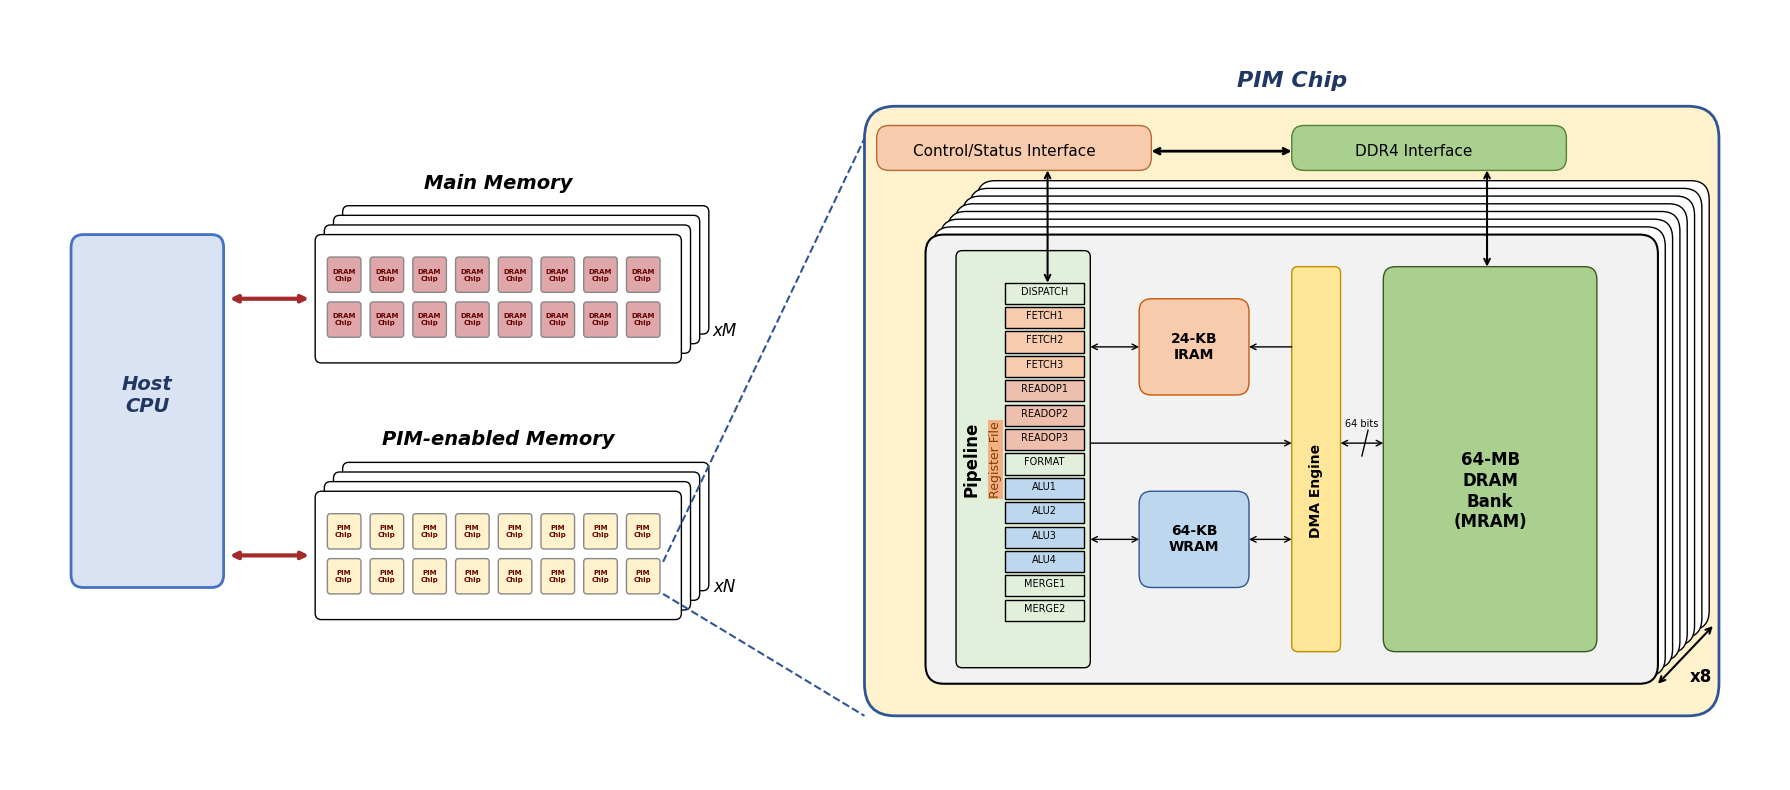

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np

# --- Configuration & Style ---
COLORS = {
    'cpu_fill': '#dae3f3',
    'cpu_edge': '#4472c4',
    'dimm_fill': '#ffffff',
    'dram_chip': '#dfa7a9',
    'pim_chip_small': '#fff2cc',
    'pim_bg': '#fff2cc',
    'pim_edge': '#2f5597',
    'interface_orange': '#f8cbad',
    'interface_green': '#a9d08e',
    'iram': '#f8cbad',
    'wram': '#bdd7ee',
    'dma': '#ffe699',
    'mram': '#a9d08e',
    'pipeline_bg': '#e2efda',
    'pipe_green': '#d6dce4',
    'text_blue': '#203764'
}

def create_rounded_rect(xy, width, height, radius=0.1, **kwargs):
    """Creates a fancy box with rounded corners."""
    return patches.FancyBboxPatch(
        xy, width, height,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        **kwargs
    )

def draw_arrow(ax, start, end, color='black', style='<->', lw=1.5, zorder=60):
    """
    Draws an arrow between two points. 
    zorder defaults to 60 to ensure arrows appear ON TOP of high-zorder rectangles.
    """
    ax.annotate(
        '', xy=end, xytext=start,
        arrowprops=dict(arrowstyle=style, color=color, lw=lw, shrinkA=0, shrinkB=0),
        zorder=zorder
    )

def add_text(ax, xy, text, size=10, color='black', weight='normal', align='center', rotation=0, zorder=50, **kwargs):
    """Adds text to the plot with explicit zorder control."""
    ax.text(xy[0], xy[1], text, fontsize=size, color=color, 
            ha=align, va='center', weight=weight, rotation=rotation, zorder=zorder, **kwargs)

# --- Drawing Components ---

def draw_left_side(ax):
    """Draws the Host CPU and Memory Banks."""
    
    # 1. Host CPU
    cpu_rect = create_rounded_rect((0, 2.0), 2.5, 5.5, radius=0.2, 
                                   facecolor=COLORS['cpu_fill'], edgecolor=COLORS['cpu_edge'], linewidth=2)
    ax.add_patch(cpu_rect)
    add_text(ax, (1.25, 5), "Host\nCPU", size=14, color=COLORS['text_blue'], weight='bold', style='italic')

    # Helper to draw a DIMM Stack
    def draw_dimm_stack(start_y, label, chip_color, stack_label, chip_text="DRAM\nChip"):
        # Draw shadow/stack effect
        for i in range(3, 0, -1):
            offset = i * 0.15
            rect = create_rounded_rect((4 + offset, start_y + offset), 6, 2, radius=0.1,
                                       facecolor='white', edgecolor='black', zorder=10-i)
            ax.add_patch(rect)
        
        # Front DIMM
        front_rect = create_rounded_rect((4, start_y), 6, 2, radius=0.1,
                                         facecolor='white', edgecolor='black', zorder=11)
        ax.add_patch(front_rect)
        
        # Draw Chips inside
        for r in range(2):
            for c in range(8):
                cx = 4.2 + c * 0.7
                cy = start_y + 1.1 - r * 0.7
                chip = create_rounded_rect((cx, cy), 0.55, 0.55, radius=0.05,
                                           facecolor=chip_color, edgecolor='#888', zorder=12)
                ax.add_patch(chip)
                if c == 0 and r == 0: 
                    add_text(ax, (cx + 0.27, cy + 0.27), chip_text, size=5, weight='bold', color='#660000', zorder=13)
                elif c < 8:
                    add_text(ax, (cx + 0.27, cy + 0.27), chip_text, size=5, weight='bold', color='#660000', zorder=13)#add_text(ax, (cx + 0.27, cy + 0.27), chip_text.replace('\n', ' '), size=4, color='#660000', zorder=13)

        # Main Labels
        add_text(ax, (7, start_y + 2.8), label, size=14, weight='bold', style='italic')
        # Arrow from CPU
        draw_arrow(ax, (2.6, start_y + 1), (3.9, start_y + 1), color='#a52a2a', lw=3)
        # Stack Label (xM / xN)
        add_text(ax, (10.7, start_y + 0.5), stack_label, size=12, style='italic')

    # Draw Main Memory
    draw_dimm_stack(5.5, "Main Memory", COLORS['dram_chip'], "xM", "DRAM\nChip")
    
    # Draw PIM Memory
    draw_dimm_stack(1.5, "PIM-enabled Memory", COLORS['pim_chip_small'], "xN", "PIM\nChip")

    # Dashed lines connecting to detail view
    src_x, src_y = 9.7, 1.9
    ax.plot([src_x, 13], [src_y, 0], color='#2f5597', linestyle='--', lw=1.5, zorder=70) 
    ax.plot([src_x, 13], [src_y + 0.5, 9], color='#2f5597', linestyle='--', lw=1.5, zorder=70)

def draw_pim_detail(ax):
    """Draws the detailed PIM Chip architecture on the right."""
    base_x, base_y = 13, 0
    width, height = 14, 9.5
    
    # Main Container
    container = create_rounded_rect((base_x, base_y), width, height, radius=0.5,
                                    facecolor=COLORS['pim_bg'], edgecolor=COLORS['pim_edge'], linewidth=2, zorder=1)
    ax.add_patch(container)
    add_text(ax, (base_x + width/2, base_y + height + 0.4), "PIM Chip", size=16, 
             color=COLORS['text_blue'], weight='bold', style='italic')

    # Top Interfaces
    # Control/Status
    cs_rect = create_rounded_rect((base_x + 0.2, base_y + 8.5), 4.5, 0.7, radius=0.2,
                                  facecolor=COLORS['interface_orange'], edgecolor='#b56a35', zorder=2)
    ax.add_patch(cs_rect)
    add_text(ax, (base_x + 2.3, base_y + 8.8), "Control/Status Interface", size=11, zorder=3)

    # DDR4
    ddr_rect = create_rounded_rect((base_x + 7, base_y + 8.5), 4.5, 0.7, radius=0.2,
                                   facecolor=COLORS['interface_green'], edgecolor='#548235', zorder=2)
    ax.add_patch(ddr_rect)
    add_text(ax, (base_x + 9, base_y + 8.8), "DDR4 Interface", size=11, zorder=3)

    # Interface Arrow
    draw_arrow(ax, (base_x + 4.7, base_y + 8.8), (base_x + 7, base_y + 8.8), style='<->', lw=2)

    # --- Internal Stack (The 3D Slices) ---
    stack_x, stack_y = base_x + 1, base_y + 0.5
    sw, sh = 12, 7
    
    # Draw background slices
    for i in range(7, 0, -1):
        off = i * 0.12
        rect = create_rounded_rect((stack_x + off, stack_y + off), sw, sh, radius=0.3,
                                   facecolor='white', edgecolor='black', linewidth=1, zorder=20-i)
        ax.add_patch(rect)
    
    # x8 Label
    add_text(ax, (stack_x + sw + 0.7, stack_y+0.1), "x8", size=12, weight='bold')
    draw_arrow(ax, (stack_x + sw, stack_y), (stack_x + sw + 0.9, stack_y + 0.9), style='<->', lw=1.5)

    # --- Front Slice Contents ---
    front_z = 30
    # Background of front slice
    front_bg = create_rounded_rect((stack_x, stack_y), sw, sh, radius=0.3,
                                   facecolor='#f2f2f2', edgecolor='black', linewidth=1.5, zorder=front_z)
    ax.add_patch(front_bg)

    # 1. Pipeline
    pipe_x = stack_x + 0.5
    pipe_w = 2.2
    pipe_h = sh - 0.5 
    pipe_rect = create_rounded_rect((pipe_x, stack_y + 0.25), pipe_w, pipe_h, radius=0.1,
                                    facecolor=COLORS['pipeline_bg'], edgecolor='black', zorder=front_z+1)
    ax.add_patch(pipe_rect)
    
    # Pipeline Rotation Text
    ax.text(pipe_x + 0.25, stack_y + pipe_h/2 + 0.25, "Pipeline", rotation=90, 
            weight='bold', size=12, va='center', ha='center', zorder=front_z+2)
    # Register File Text
    ax.text(pipe_x + 0.65, stack_y + pipe_h/2 + 0.25, "Register File", rotation=90, 
            size=9, va='center', ha='center', color='#7b3f00', bbox=dict(boxstyle='square,pad=0.1', fc='#f4b084', ec='none'), zorder=front_z+2)

    # Pipeline Stages
    stages = [
        ('DISPATCH', '#e2efda'), ('FETCH1', '#f8cbad'), ('FETCH2', '#f8cbad'), ('FETCH3', '#f8cbad'),
        ('READOP1', '#eebfac'), ('READOP2', '#eebfac'), ('READOP3', '#eebfac'),
        ('FORMAT', '#e2efda'), ('ALU1', '#bdd7ee'), ('ALU2', '#bdd7ee'), 
        ('ALU3', '#bdd7ee'), ('ALU4', '#bdd7ee'), ('MERGE1', '#e2efda'), ('MERGE2', '#e2efda')
    ]
    
    stage_h = 0.38
    start_stage_y = stack_y + pipe_h - 0.2
    
    for i, (text, color) in enumerate(stages):
        y_pos = start_stage_y - (i+1) * stage_h
        rect = patches.Rectangle((pipe_x + 0.8, y_pos), 1.3, stage_h-0.05, 
                                 facecolor=color, edgecolor='black', zorder=front_z+3)
        ax.add_patch(rect)
        add_text(ax, (pipe_x + 1.45, y_pos + stage_h/2), text, size=7, zorder=front_z+4)

    # 2. IRAM
    iram_x = pipe_x + pipe_w + 0.8
    iram_y = stack_y + 4.5
    iram = create_rounded_rect((iram_x, iram_y), 1.8, 1.5, radius=0.2,
                               facecolor=COLORS['iram'], edgecolor='#c65911', zorder=front_z+1)
    ax.add_patch(iram)
    add_text(ax, (iram_x + 0.9, iram_y + 0.75), "24-KB\nIRAM", weight='bold', size=10, zorder=front_z+2)

    # 3. WRAM
    wram_y = stack_y + 1.5
    wram = create_rounded_rect((iram_x, wram_y), 1.8, 1.5, radius=0.2,
                               facecolor=COLORS['wram'], edgecolor='#2f5597', zorder=front_z+1)
    ax.add_patch(wram)
    add_text(ax, (iram_x + 0.9, wram_y + 0.75), "64-KB\nWRAM", weight='bold', size=10, zorder=front_z+2)

    # 4. DMA Engine
    dma_x = iram_x + 2.5
    dma = create_rounded_rect((dma_x, stack_y + 0.5), 0.8, 6, radius=0.1,
                              facecolor=COLORS['dma'], edgecolor='#bf9000', zorder=front_z+1)
    ax.add_patch(dma)
    ax.text(dma_x + 0.4, stack_y + 3, "DMA Engine", rotation=90, weight='bold', 
            va='center', ha='center', zorder=front_z+2)

    # 5. MRAM
    mram_x = dma_x + 1.5
    mram = create_rounded_rect((mram_x, stack_y + 0.5), 3.5, 6, radius=0.2,
                               facecolor=COLORS['mram'], edgecolor='#385723', zorder=front_z+1)
    ax.add_patch(mram)
    add_text(ax, (mram_x + 1.75, stack_y + 3), "64-MB\nDRAM\nBank\n(MRAM)", weight='bold', size=12, zorder=front_z+2)

    # --- Internal Arrows ---
    # Top Interface to Pipeline/IRAM/DMA
    # Arrow to Dispatch
    draw_arrow(ax, (pipe_x + 1.5, base_y + 8.5), (pipe_x + 1.5, stack_y + pipe_h - 0.25), style='<->')
    # Arrow to DDR4/MRAM
    draw_arrow(ax, (mram_x + 1.7, base_y + 8.5), (mram_x + 1.7, stack_y + 6.5), style='<->')

    # Pipeline <-> IRAM
    draw_arrow(ax, (pipe_x + 2.2, iram_y + 0.75), (iram_x, iram_y + 0.75), style='<->', lw=1)
    # Pipeline <-> WRAM
    draw_arrow(ax, (pipe_x + 2.2, wram_y + 0.75), (iram_x, wram_y + 0.75), style='<->', lw=1)
    # Pipeline -> DMA
    draw_arrow(ax, (pipe_x + 2.2, wram_y + 2.25), (dma_x, wram_y + 2.25), style='->', lw=1)
    
    # IRAM <-> DMA
    draw_arrow(ax, (iram_x + 1.8, iram_y + 0.75), (dma_x, iram_y + 0.75), style='<-', lw=1)
    # WRAM <-> DMA
    draw_arrow(ax, (iram_x + 1.8, wram_y + 0.75), (dma_x, wram_y + 0.75), style='<->', lw=1)
    
    # DMA <-> MRAM
    draw_arrow(ax, (dma_x + 0.8, wram_y + 2.25), (mram_x, wram_y + 2.25), style='<->', lw=1)
    
    # 64 bits label and slash
    add_text(ax, (dma_x + 1.15, wram_y + 2.55), "64 bits", size=7, zorder=60)
    ax.plot([dma_x + 1.15, dma_x + 1.25], [wram_y + 2.05, wram_y + 2.45], color='black', lw=1, zorder=60)


def generate_diagram():
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.set_xlim(-1, 28)
    ax.set_ylim(-1, 11)
    ax.axis('off')
    
    # Draw Left Section
    draw_left_side(ax)
    
    # Draw Right Section
    draw_pim_detail(ax)

    plt.tight_layout()
    return fig

# --- Main Execution ---
if __name__ == "__main__":
    fig = generate_diagram()
    fig.savefig("upmem_arch.svg", bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

In [1]:
import numpy as np

# Set seed for reproducibility (optional, remove for different runs)
np.random.seed(42)

# Number of families to simulate (larger = more accurate)
N = 1_000_000

print("=== Monte Carlo Simulations for the Boy-Girl Paradox ===")
print(f"Simulating {N:,} families...\n")

# Each child: gender (0 = girl, 1 = boy) and weekday (0-6)
# We generate genders and weekdays separately
genders = np.random.randint(0, 2, size=(N, 2))  # 0=girl, 1=boy
weekdays = np.random.randint(0, 7, size=(N, 2))  # 0-6 for days

# Tuesday = day 2 (arbitrary, doesn't matter)
TUESDAY = 2

# --------------------------------------------------
# Case 1: Specific child identified as boy → should be ~50%
# --------------------------------------------------
# Randomly select one child per family to "observe"
observed_idx = np.random.randint(0, 2, size=N)
observed_gender = genders[np.arange(N), observed_idx]

# Condition on observed child being boy
boy_observed_mask = observed_gender == 1
families_with_observed_boy = genders[boy_observed_mask]

# The "other" child is the one not observed
other_idx = 1 - observed_idx[boy_observed_mask]
other_gender = families_with_observed_boy[np.arange(len(families_with_observed_boy)), other_idx]

prob_other_girl_specific = np.mean(other_gender == 0)
print("Case 1: Specific child is boy")
print(f"  Families with observed boy: {len(families_with_observed_boy):,}")
print(f"  P(other is girl | specific child boy) ≈ {prob_other_girl_specific:.5f}")
print(f"  (Expected: exactly 0.5)\n")

# --------------------------------------------------
# Case 2: At least one boy (no specific child) → should be ~2/3
# --------------------------------------------------
at_least_one_boy_mask = np.any(genders == 1, axis=1)
families_at_least_one_boy = genders[at_least_one_boy_mask]

num_mixed_classic = np.sum(np.sum(families_at_least_one_boy == 1, axis=1) == 1)
prob_mixed_classic = num_mixed_classic / len(families_at_least_one_boy)

print("Case 2: At least one boy (classic paradox)")
print(f"  Families with ≥1 boy: {len(families_at_least_one_boy):,}")
print(f"  P(mixed genders | ≥1 boy) ≈ {prob_mixed_classic:.5f}")
print(f"  (Expected: exactly 2/3 ≈ 0.66667)\n")

# --------------------------------------------------
# Case 3: At least one Tuesday boy → should be ~14/27 ≈ 0.51852
# --------------------------------------------------
tuesday_boy = (genders == 1) & (weekdays == TUESDAY)
at_least_one_tuesday_boy_mask = np.any(tuesday_boy, axis=1)
families_at_least_one_tb = genders[at_least_one_tuesday_boy_mask]

num_mixed_tuesday = np.sum(np.sum(families_at_least_one_tb == 1, axis=1) == 1)
prob_mixed_tuesday = num_mixed_tuesday / len(families_at_least_one_tb)

print("Case 3: At least one boy born on Tuesday")
print(f"  Families with ≥1 Tuesday boy: {len(families_at_least_one_tb):,}")
print(f"  P(mixed genders | ≥1 Tuesday boy) ≈ {prob_mixed_tuesday:.5f}")
print(f"  (Expected: exactly 14/27 ≈ 0.51852)")

=== Monte Carlo Simulations for the Boy-Girl Paradox ===
Simulating 1,000,000 families...

Case 1: Specific child is boy
  Families with observed boy: 499,936
  P(other is girl | specific child boy) ≈ 0.49976
  (Expected: exactly 0.5)

Case 2: At least one boy (classic paradox)
  Families with ≥1 boy: 749,706
  P(mixed genders | ≥1 boy) ≈ 0.66642
  (Expected: exactly 2/3 ≈ 0.66667)

Case 3: At least one boy born on Tuesday
  Families with ≥1 Tuesday boy: 137,173
  P(mixed genders | ≥1 Tuesday boy) ≈ 0.51802
  (Expected: exactly 14/27 ≈ 0.51852)


In [7]:
import numpy as np

# Set seed for reproducibility (optional, remove for different runs)
np.random.seed(42)

# Number of families to simulate (larger = more accurate)
N = 20

print("=== Monte Carlo Simulations for the Boy-Girl Paradox ===")
print(f"Simulating {N:,} families...\n")

# Each child: gender (0 = girl, 1 = boy) and weekday (0-6)
# We generate genders and weekdays separately
genders = np.random.randint(0, 2, size=(N, 2))  # 0=girl, 1=boy

print("Geneders = ", genders)

# --------------------------------------------------
# Case 1: Specific child identified as boy → should be ~50%
# --------------------------------------------------
# Randomly select one child per family to "observe"
observed_idx = np.random.randint(0, 2, size=N)
observed_gender = genders[np.arange(N), observed_idx]

# Condition on observed child being boy
boy_observed_mask = observed_gender == 1
families_with_observed_boy = genders[boy_observed_mask]

# The "other" child is the one not observed
other_idx = 1 - observed_idx[boy_observed_mask]
other_gender = families_with_observed_boy[np.arange(len(families_with_observed_boy)), other_idx]

prob_other_girl_specific = np.mean(other_gender == 0)
print("Case 1: Specific child is boy")
print(f"  Families with observed boy: {len(families_with_observed_boy):,}")
print(f"  P(other is girl | specific child boy) ≈ {prob_other_girl_specific:.5f}")
print(f"  (Expected: exactly 0.5)\n")

# --------------------------------------------------
# Case 2: At least one boy (no specific child) → should be ~2/3
# --------------------------------------------------
at_least_one_boy_mask = np.any(genders == 1, axis=1)
families_at_least_one_boy = genders[at_least_one_boy_mask]

num_mixed_classic = np.sum(np.sum(families_at_least_one_boy == 1, axis=1) == 1)
prob_mixed_classic = num_mixed_classic / len(families_at_least_one_boy)

print("Case 2: At least one boy (classic paradox)")
print(f"  Families with ≥1 boy: {len(families_at_least_one_boy):,}")
print(f"  P(mixed genders | ≥1 boy) ≈ {prob_mixed_classic:.5f}")
print(f"  (Expected: exactly 2/3 ≈ 0.66667)\n")


=== Monte Carlo Simulations for the Boy-Girl Paradox ===
Simulating 20 families...

Geneders =  [[0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [1 0]
 [0 0]]
Case 1: Specific child is boy
  Families with observed boy: 12
  P(other is girl | specific child boy) ≈ 0.50000
  (Expected: exactly 0.5)

Case 2: At least one boy (classic paradox)
  Families with ≥1 boy: 14
  P(mixed genders | ≥1 boy) ≈ 0.57143
  (Expected: exactly 2/3 ≈ 0.66667)



In [50]:
import random
def weight_balls(balls, i, j):
    sum = 0
    for x in range(i,j+1):
        sum += balls[str(x)]
    return sum

def find_heavy_ball(BALLS):
    weight_1_3 = weight_balls(BALLS,1,3)
    weight_4_6 = weight_balls(BALLS,4,6)


    if weight_1_3 == weight_4_6:
        if BALLS["7"] > BALLS["8"]:
            print("Ball 8: ", BALLS["8"])
        else:
            print("Ball 8: ", BALLS["8"])
    elif weight_1_3 > weight_4_6:
        if BALLS["1"] == BALLS["2"]:
            print("Ball 3: ", BALLS["3"])
        elif BALLS["1"] > BALLS["2"]:
            print("Ball 1: ", BALLS["1"])
        else:
            print("Ball 2: ", BALLS["2"])
    else:
        if BALLS["4"] == BALLS["5"]:
            print("Ball 6: ", BALLS["6"])
        elif BALLS["4"] > BALLS["5"]:
            print("Ball 4: ", BALLS["4"])
        else:
            print("Ball 5: ", BALLS["5"])

In [58]:

BALLS = {   "1": 1,
            "2": 1,
            "3": 1,
            "4": 1,
            "5": 1,
            "6": 1,
            "7": 1,
            "8": 1}

BALLS[str(random.randint(1,8))] += 1
print(BALLS)

find_heavy_ball(BALLS)

{'1': 1, '2': 1, '3': 1, '4': 1, '5': 1, '6': 1, '7': 2, '8': 1}
Ball 8:  1
